In [1]:
import pickle as pickle
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import csv
from mpl_toolkits.axes_grid1 import host_subplot
from matplotlib import rcParams

from defs import generate_k_space_sweep, visualize_sweep, rotate_points

%load_ext autoreload
%autoreload 2

In [2]:
data_dir = '../../../data/simulation/'
out_dir = '../../../output/paper_upload/'

In [3]:
# Load COMSOL-simulated kagome band structure data from csv file

b_sim = np.zeros(0)  # Initialize an empty array for b_sim
bands_sim = np.zeros((3, 0))  # Initialize an empty array with 3 rows

with open(data_dir+'kagome_machine_bands_clean.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)

    for row in reader:
        b_sim = np.hstack((b_sim, float(row[0])))
        bands_sim = np.hstack((bands_sim, np.array([[float(row[1])], [float(row[2])], [float(row[3])]])))


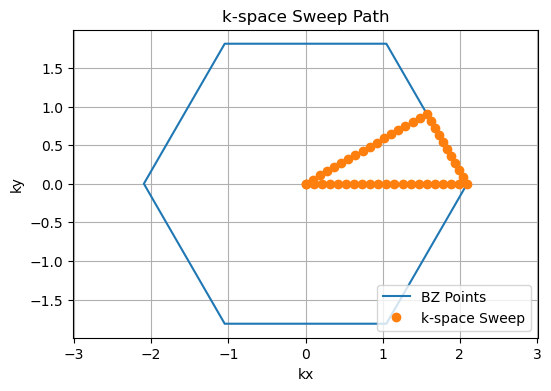

In [8]:
# Define the points in reciprocal space for the sweep
L = 1
G = np.array([0, 0])
K = np.array([2*np.pi/(3*L), 0])
M = np.array([3/2*np.pi/3/L, np.pi/np.sqrt(3)/2/L])


rcParams.update({'font.size': 10, 'axes.labelsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

b_TB, kx_TB, ky_TB = generate_k_space_sweep([G, K, M, G], num_points=len(b_sim))
BZ_points = rotate_points(K, np.linspace(0, 2*np.pi, 7, endpoint=True))
visualize_sweep((kx_TB, ky_TB), BZ_points)

In [9]:
bands_TB = np.zeros((3, len(kx_TB)))  # Placeholder for band energies
t = 1

for i, (kx, ky) in tqdm(enumerate(zip(kx_TB, ky_TB))):
    M = -t*np.array([[0, 1+np.exp(-1j*2*kx*L), 1+np.exp(-1j*(kx-np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*2*kx*L), 0, 1+np.exp(1j*(kx+np.sqrt(3)*ky)*L)],
                     [1+np.exp(1j*(kx-np.sqrt(3)*ky)*L), 1+np.exp(-1j*(kx+np.sqrt(3)*ky)*L), 0]])

    bands_TB[:,i] = np.linalg.eigvalsh(M)

0it [00:00, ?it/s]

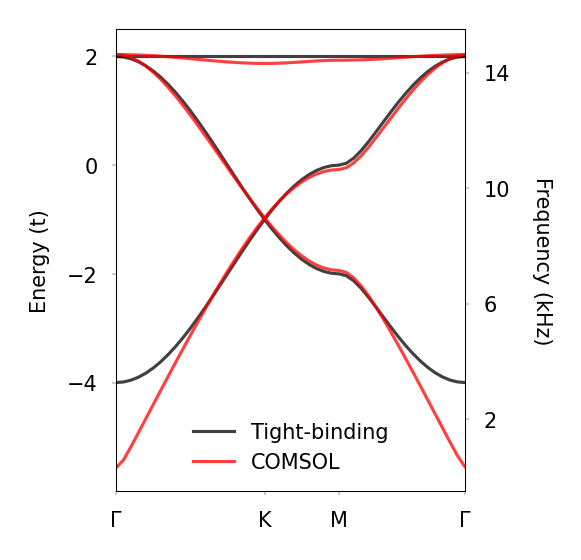

In [10]:
# Set figure size and DPI when creating the figure
rcParams.update({'font.size': 5, 'axes.labelsize': 5, 'xtick.labelsize': 5, 'ytick.labelsize': 5})
fig = plt.figure(figsize=(1.5, 2), dpi=300)
host = host_subplot(111)
par = host.twinx()

# Set axis limits, ticks, and tick parameters
host.set_xlim(0, b_sim[-1])
host.set_ylim(-6, 2.5)
par.set_ylim(-0.5, 15.5)
host.set_ylabel('Energy (t)')
par.set_ylabel('Frequency (kHz)', rotation=270, labelpad=10)
host.set_xticks([0, 1, 1.5 , b_sim[-1]], ['Γ', 'K', 'M', 'Γ'])
host.set_yticks(np.linspace(-4, 2, 4, endpoint=True))
par.set_yticks(np.linspace(2, 14, 4, endpoint=True))
host.xaxis.set_tick_params(width=0.1, length = 1)
host.yaxis.set_tick_params(width=0.1, length = 1)
par.yaxis.set_tick_params(width=0.1, length = 1)

for axis in ['top','bottom','left','right']:
    host.spines[axis].set_linewidth(0.25)
    par.spines[axis].set_linewidth(0.25)


# Plot the tight-binding and COMSOL-simulated band structures
for i in range(len(bands_sim)):
    host.plot(b_sim, bands_TB[i], 'k-', linewidth=0.75, alpha=0.75, label='Tight-binding' if i == 0 else None)
    par.plot(b_sim, bands_sim[i], 'r-', linewidth=0.75, alpha=0.75, label='COMSOL' if i == 0 else None)

host.legend(loc='lower center', frameon=False)
plt.savefig(out_dir+"kagome_bands_intro.pdf")
plt.show()